# BC historical weather
ERA5-Seamless reanalysis (Copernicus/ECMWF), which assimilates satellite observations, via Open-Meteo.
Run cells in order with the environment from `requirements.txt`. No API key is needed.
[Official archive docs](https://open-meteo.com/en/docs/historical-weather-api) and
[official OpenAPI model enum](https://github.com/open-meteo/open-meteo/blob/main/openapi/historical-weather.yml).
ERA5-Seamless combines ERA5-Land temperature/humidity with ERA5 wind. No gusts are requested.

## 1. Config

In [ ]:
# Defaults; papermill overrides these (see run_weather.py).
YEAR = 2023
START = "2023-05-01"
END = "2023-10-31"

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import time as clock
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from IPython.display import display

folder = Path.cwd().resolve()
REPO_ROOT = next((p for p in (folder, *folder.parents)
                  if (p / "CLAUDE.md").is_file()), None)
if REPO_ROOT is None:
    raise RuntimeError("Launch from the repository root or data folder.")
sys.path.insert(0, str(REPO_ROOT / "notebooks"))
from bc_geo import BC_BBOX, load_bc_boundary
from datetime import date
# YEAR, START and END come from the parameters cell above; papermill passes dates as strings.
START, END = (date.fromisoformat(str(day)) for day in (START, END))

GRID_STEP = 0.5
BATCH_SIZE = 50
MODEL = "era5_seamless"
API_URL = "https://archive-api.open-meteo.com/v1/archive"
VARIABLES = ["temperature_2m", "relative_humidity_2m", "wind_speed_10m", "wind_direction_10m"]
CACHE_DIR = REPO_ROOT / "data" / "raw" / "weather" / "cache"
OUTPUT_DIR = REPO_ROOT / "data" / "raw" / "weather"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SESSION = requests.Session()
EXPECTED_TIMES = pd.date_range(pd.Timestamp(START, tz="UTC"),
                               pd.Timestamp(END, tz="UTC") + pd.Timedelta(hours=23), freq="h")

## 2. Build the grid

Grid: 569 points; 4416 hours per point.


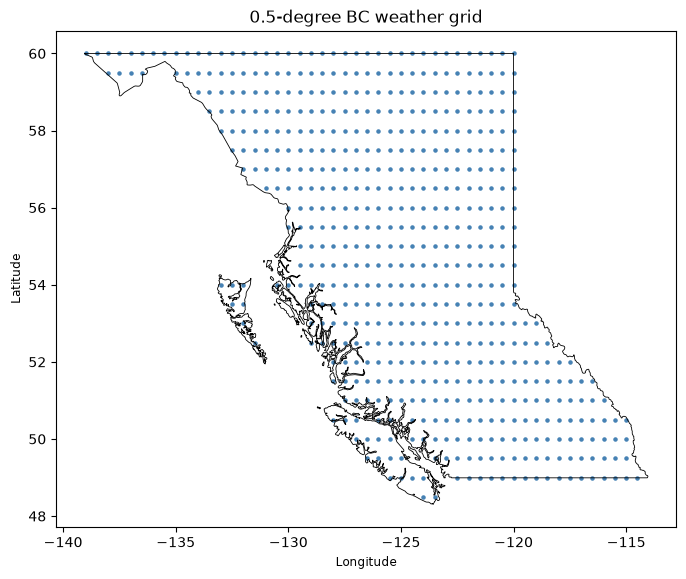

In [2]:
bc = load_bc_boundary()
west, south, east, north = map(float, BC_BBOX.split(","))
# Anchor at half-degree multiples; avoid floating-point drift.
lons = np.arange(np.ceil(west / GRID_STEP), np.floor(east / GRID_STEP) + 1) * GRID_STEP
lats = np.arange(np.ceil(south / GRID_STEP), np.floor(north / GRID_STEP) + 1) * GRID_STEP
lon_mesh, lat_mesh = np.meshgrid(lons, lats)
candidates = gpd.GeoDataFrame({"lat": lat_mesh.ravel(), "lon": lon_mesh.ravel()},
    geometry=gpd.points_from_xy(lon_mesh.ravel(), lat_mesh.ravel()), crs="EPSG:4326")
grid = gpd.sjoin(candidates, bc, how="inner", predicate="within").drop(columns="index_right")
grid = grid.sort_values(["lat", "lon"]).reset_index(drop=True)
if grid.empty:
    raise RuntimeError("No grid points inside BC.")
print(f"Grid: {len(grid)} points; {len(EXPECTED_TIMES)} hours per point.")
ax = bc.boundary.plot(figsize=(8, 8), color="black", linewidth=0.6)
grid.plot(ax=ax, markersize=5, color="steelblue")
ax.set(title="0.5-degree BC weather grid", xlabel="Longitude", ylabel="Latitude")
plt.show()

## 3. Download monthly batches
Comma-separated latitude/longitude lists produce a list of per-location responses in request order.
Each batch/month is cached under `data/raw/cache/weather/`; request parameters determine the cache identity.
The API defaults to GMT (timezone is omitted). Units are explicitly Celsius and km/h.
Returned grid-cell coordinates may differ from the requested BC points; both are retained.
A request counter includes retry attempts, but is not the API's weighted quota count.
Long date ranges and multiple locations consume multiple calls ([limits](https://open-meteo.com/en/pricing)).

In [3]:
month_windows = []
for month in pd.date_range(pd.Timestamp(START).replace(day=1), END, freq="MS"):
    month_start = max(START, month.date())
    month_end = min(END, (month + pd.offsets.MonthEnd(0)).date())
    month_windows.append((month_start, month_end))
batches = [grid.iloc[i:i + BATCH_SIZE] for i in range(0, len(grid), BATCH_SIZE)]
REQUEST_COUNT = 0
PAUSE_SECONDS = 12  # Pace 50-location monthly requests; batching doesn't reduce weighted quota.


def request_params(batch, start, end):
    return {
        "latitude": ",".join(batch.lat.map(lambda v: f"{v:.4f}")),
        "longitude": ",".join(batch.lon.map(lambda v: f"{v:.4f}")),
        "start_date": start.isoformat(), "end_date": end.isoformat(),
        "models": MODEL, "hourly": ",".join(VARIABLES),
        "temperature_unit": "celsius", "wind_speed_unit": "kmh",
        # timezone omitted: Open-Meteo defaults to GMT, matching FIRMS UTC.
    }


def parse_batch(payload, batch, start, end):
    if isinstance(payload, dict) and payload.get("error"):
        raise ValueError(f"Open-Meteo: {payload.get('reason', 'Unknown error')}")
    locations = payload if isinstance(payload, list) else [payload]
    if len(locations) != len(batch):
        raise ValueError("Response location count differs from requested batch.")
    expected = pd.date_range(pd.Timestamp(start, tz="UTC"),
                             pd.Timestamp(end, tz="UTC") + pd.Timedelta(hours=23), freq="h")
    frames = []
    specs = [("temperature_2m", "temp_c", "\u00b0C"),
             ("relative_humidity_2m", "rh_pct", "%"),
             ("wind_speed_10m", "wind_kmh", "km/h"),
             ("wind_direction_10m", "wind_from_deg", "\u00b0")]
    for point, location in zip(batch.itertuples(index=False), locations):
        if location.get("error"):
            raise ValueError(location.get("reason", "Unknown API error"))
        if location.get("utc_offset_seconds") != 0:
            raise ValueError("Response timestamps are not GMT.")
        hourly = location["hourly"]
        times = pd.DatetimeIndex(pd.to_datetime(hourly["time"], utc=True))
        if not times.equals(expected):
            raise ValueError("Missing, duplicate, or unexpected hourly timestamps.")
        grid_lat, grid_lon = float(location["latitude"]), float(location["longitude"])
        if not (-90 <= grid_lat <= 90 and -180 <= grid_lon <= 180):
            raise ValueError("Invalid returned grid-cell coordinates.")
        data = {"time_utc": times, "req_lat": point.lat, "req_lon": point.lon,
                "grid_lat": grid_lat, "grid_lon": grid_lon}
        for variable, column, unit in specs:
            values = hourly.get(variable)
            if not isinstance(values, list) or len(values) != len(times):
                raise ValueError(f"Missing or invalid array: {variable}")
            if location["hourly_units"].get(variable) != unit:
                raise ValueError(f"Unexpected units: {variable}")
            data[column] = pd.to_numeric(pd.Series(values), errors="raise").to_numpy(dtype=float)
        frames.append(pd.DataFrame(data))
    return pd.concat(frames, ignore_index=True)


class OpenMeteoLimitError(RuntimeError):
    """Open-Meteo rate limit reached. Stop now and rerun later; cached batches are kept."""


def download_batch(params, batch, start, end, attempts=5):
    global REQUEST_COUNT
    for attempt in range(attempts):
        REQUEST_COUNT += 1
        print(f"HTTP request #{REQUEST_COUNT}, attempt {attempt + 1}/{attempts}")
        delay = min(60, 5 * 2 ** attempt)
        try:
            response = SESSION.get(API_URL, params=params, timeout=(15, 180))
        except requests.RequestException:
            reason = "Open-Meteo network error."
        else:
            try:
                payload = response.json()
            except ValueError:
                payload = None
            reason = (payload.get("reason", response.text[:1000])
                      if isinstance(payload, dict) else response.text[:1000])
            if response.status_code == 429 or (isinstance(payload, dict) and payload.get("error")
                                               and "limit" in str(reason).lower()):
                # No retries: more requests only extend the block.
                raise OpenMeteoLimitError(
                    f"Open-Meteo limit reached in {YEAR}, month {start:%Y-%m}, "
                    f"batch {batch_number}/{len(batches)}: {reason}")
            if response.status_code == 200:
                if isinstance(payload, dict) and payload.get("error"):
                    raise RuntimeError(f"Open-Meteo error: {reason}")
                parse_batch(payload, batch, start, end)  # Validate before caching.
                return payload
            if response.status_code == 400:
                raise RuntimeError(f"Open-Meteo HTTP 400: {reason}")
            if response.status_code != 429 and response.status_code < 500:
                raise RuntimeError(f"Open-Meteo HTTP {response.status_code}: {reason}")
            if response.status_code == 429:
                try:
                    delay = max(delay, float(response.headers.get("Retry-After", delay)))
                except ValueError:
                    pass
                if delay > 60:
                    raise RuntimeError(f"Rate limit: {reason}. Rerun later; completed caches are retained.")
            reason = f"HTTP {response.status_code}: {reason}"
        print(reason)
        if attempt + 1 < attempts:
            print(f"Retry in {delay:g}s")
            clock.sleep(delay)
    raise RuntimeError(reason)

batch_tables = []
total = len(batches) * len(month_windows)
completed = 0
for start, end in month_windows:
    for batch_number, batch in enumerate(batches, start=1):
        params = request_params(batch, start, end)
        identity = json.dumps({"endpoint": API_URL, "params": params}, sort_keys=True)
        digest = hashlib.sha256(identity.encode()).hexdigest()[:20]
        cache_path = CACHE_DIR / f"{MODEL}_{start}_{end}_{digest}.json"
        if cache_path.exists():
            payload = json.loads(cache_path.read_text(encoding="utf-8"))
            origin = "cache"
        else:
            payload = download_batch(params, batch, start, end)
            temp_path = cache_path.with_suffix(".tmp")
            temp_path.write_text(json.dumps(payload), encoding="utf-8")
            temp_path.replace(cache_path)
            origin = "download"
            clock.sleep(PAUSE_SECONDS)
        batch_tables.append(parse_batch(payload, batch, start, end))
        completed += 1
        print(f"{completed}/{total}: {start:%Y-%m}, batch {batch_number}/{len(batches)} "
              f"({origin}); HTTP requests so far: {REQUEST_COUNT}")

HTTP request #1, attempt 1/5


1/72: 2023-05, batch 1/12 (download); HTTP requests so far: 1
HTTP request #2, attempt 1/5


2/72: 2023-05, batch 2/12 (download); HTTP requests so far: 2
HTTP request #3, attempt 1/5


3/72: 2023-05, batch 3/12 (download); HTTP requests so far: 3
HTTP request #4, attempt 1/5


4/72: 2023-05, batch 4/12 (download); HTTP requests so far: 4
HTTP request #5, attempt 1/5


...

68/72: 2023-10, batch 8/12 (download); HTTP requests so far: 68
HTTP request #69, attempt 1/5


69/72: 2023-10, batch 9/12 (download); HTTP requests so far: 69
HTTP request #70, attempt 1/5


70/72: 2023-10, batch 10/12 (download); HTTP requests so far: 70
HTTP request #71, attempt 1/5


71/72: 2023-10, batch 11/12 (download); HTTP requests so far: 71
HTTP request #72, attempt 1/5


72/72: 2023-10, batch 12/12 (download); HTTP requests so far: 72


## 4. Combine

In [4]:
weather = pd.concat(batch_tables, ignore_index=True).sort_values(
    ["time_utc", "req_lat", "req_lon"]).reset_index(drop=True)
if weather.duplicated(["time_utc", "req_lat", "req_lon"]).any():
    raise ValueError("Duplicate requested-location/time records.")
if len(weather) != len(grid) * len(EXPECTED_TIMES):
    raise ValueError("Incomplete seasonal hourly coverage.")
print(f"Combined {len(weather):,} hourly weather records.")
display(weather.head())

Combined 2,512,704 hourly weather records.


,time_utc,req_lat,req_lon,grid_lat,grid_lon,temp_c,rh_pct,wind_kmh,wind_from_deg
0,2023-05-01 00:00:00+00:00,48.5,-124.0,48.5,-124.0,10.6,67.0,14.8,267.0
1,2023-05-01 00:00:00+00:00,48.5,-123.5,48.5,-123.5,11.1,71.0,10.1,264.0
2,2023-05-01 00:00:00+00:00,49.0,-125.5,49.0,-125.5,6.9,71.0,10.1,182.0
3,2023-05-01 00:00:00+00:00,49.0,-125.0,49.0,-125.0,12.3,63.0,10.8,195.0
4,2023-05-01 00:00:00+00:00,49.0,-124.5,49.0,-124.5,6.3,58.0,11.5,219.0


## 5. Spread direction

In [5]:
# Weather wind direction is where wind blows FROM, clockwise from north.
# Fire spreads TOWARD the opposite bearing. Getting this backwards spreads fires into the wind.
weather["spread_to_deg"] = (weather["wind_from_deg"] + 180) % 360

## 6. Sanity checks

,temp_c,rh_pct,wind_kmh,wind_from_deg,spread_to_deg
count,2.512704e+06,2.512704e+06,2.512704e+06,2.512704e+06,2.512704e+06
mean,1.036970e+01,6.985748e+01,6.595998e+00,2.000336e+02,1.443069e+02
std,7.481501e+00,2.066023e+01,4.053986e+00,8.735175e+01,1.089344e+02
min,-2.940000e+01,7.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,5.600000e+00,5.400000e+01,3.800000e+00,1.420000e+02,5.300000e+01
50%,1.060000e+01,7.200000e+01,5.700000e+00,2.170000e+02,1.050000e+02
75%,1.540000e+01,8.800000e+01,8.500000e+00,2.610000e+02,2.390000e+02
max,3.830000e+01,1.000000e+02,7.270000e+01,3.600000e+02,3.590000e+02


Missing values (retained, not filled):


time_utc         0
req_lat          0
req_lon          0
grid_lat         0
grid_lon         0
temp_c           0
rh_pct           0
wind_kmh         0
wind_from_deg    0
spread_to_deg    0
dtype: int64

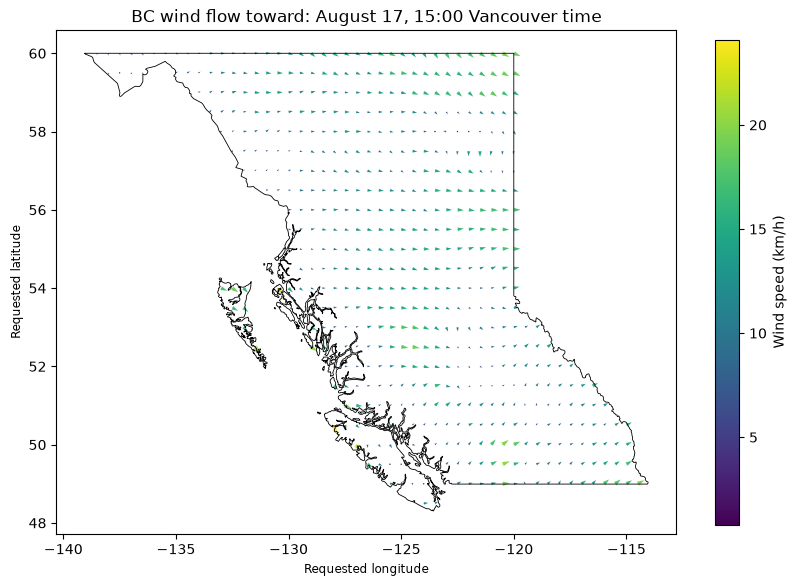

Kelowna requested point: 50.0, -119.5; 12.5 km from city.


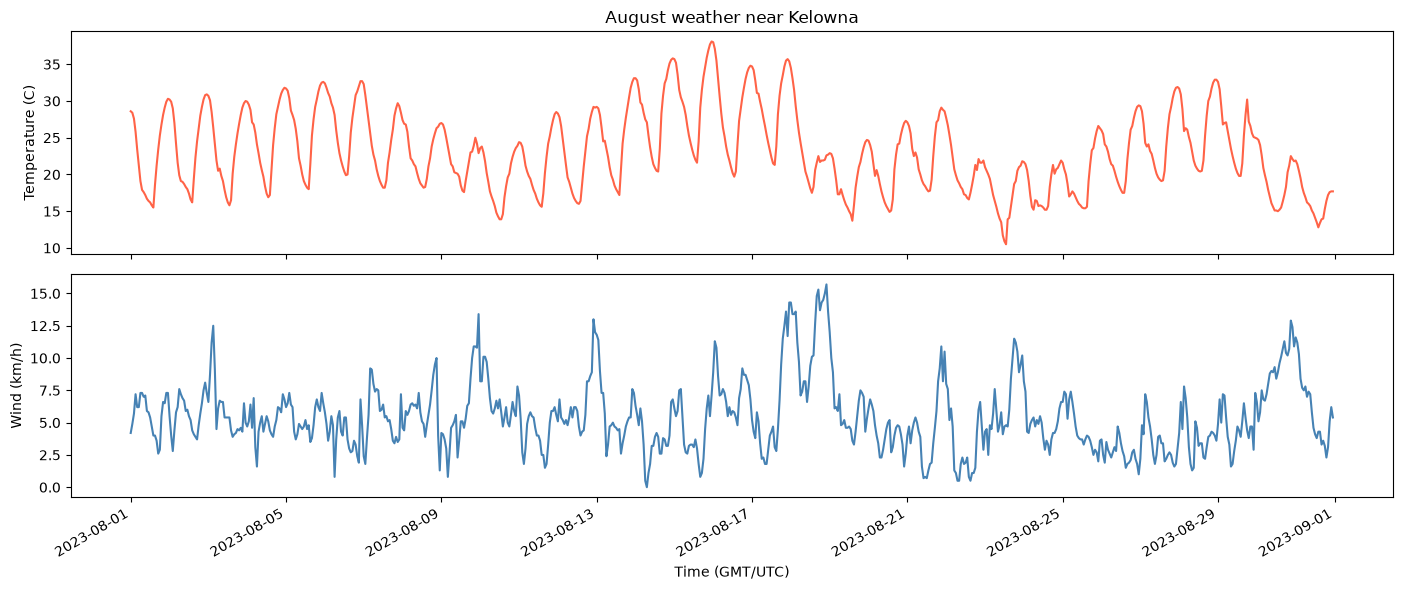

In [6]:
variables = ["temp_c", "rh_pct", "wind_kmh", "wind_from_deg", "spread_to_deg"]
display(weather[variables].describe())
print("Missing values (retained, not filled):")
display(weather.isna().sum())
for column, low, high in [("rh_pct", 0, 100), ("wind_from_deg", 0, 360)]:
    values = weather[column].dropna()
    if not values.between(low, high).all():
        raise ValueError(f"Out-of-range {column}")
if (weather.wind_kmh.dropna() < 0).any():
    raise ValueError("Negative wind speeds.")
if np.isinf(weather[variables].to_numpy()).any():
    raise ValueError("Infinite weather values.")

map_time = pd.Timestamp(f"{YEAR}-08-17 15:00", tz="America/Vancouver").tz_convert("UTC")
afternoon = weather[weather.time_utc == map_time].dropna(subset=["wind_kmh", "spread_to_deg"])
if afternoon.empty:
    raise ValueError("No valid wind data for the afternoon map.")
toward = np.deg2rad(afternoon.spread_to_deg)
u = afternoon.wind_kmh * np.sin(toward)  # eastward flow
v = afternoon.wind_kmh * np.cos(toward)  # northward flow
reference_lat = grid.lat.mean()
fig, ax = plt.subplots(figsize=(10, 9))
bc.boundary.plot(ax=ax, color="black", linewidth=0.6)
# Latitude/longitude display: scale eastward components and aspect consistently.
ax.set_aspect(1 / np.cos(np.deg2rad(reference_lat)))
arrows = ax.quiver(afternoon.req_lon, afternoon.req_lat,
    u / np.cos(np.deg2rad(reference_lat)), v, afternoon.wind_kmh,
    angles="xy", scale_units="xy", scale=100, cmap="viridis", width=0.0025)
fig.colorbar(arrows, ax=ax, label="Wind speed (km/h)", shrink=0.7)
ax.set(title="BC wind flow toward: August 17, 15:00 Vancouver time",
       xlabel="Requested longitude", ylabel="Requested latitude")
plt.show()

kelowna = gpd.GeoSeries(gpd.points_from_xy([-119.496], [49.888]),
                       crs="EPSG:4326").to_crs("EPSG:3005").iloc[0]
distances = grid.to_crs("EPSG:3005").distance(kelowna)
nearest = grid.loc[distances.idxmin()]
august_start = pd.Timestamp(f"{YEAR}-08-01", tz="UTC")
august_end = august_start + pd.offsets.MonthBegin(1)
series = weather[(weather.req_lat == nearest.lat) & (weather.req_lon == nearest.lon)
    & weather.time_utc.between(august_start, august_end, inclusive="left")].sort_values("time_utc")
print(f"Kelowna requested point: {nearest.lat}, {nearest.lon}; {distances.min()/1000:.1f} km from city.")
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(series.time_utc, series.temp_c, color="tomato")
axes[0].set(title="August weather near Kelowna", ylabel="Temperature (C)")
axes[1].plot(series.time_utc, series.wind_kmh, color="steelblue")
axes[1].set(ylabel="Wind (km/h)", xlabel="Time (GMT/UTC)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 7. Save

In [7]:
output_path = OUTPUT_DIR / f"weather_bc_{YEAR}.parquet"
weather.attrs.update({"provider": "Open-Meteo", "model": MODEL,
    "source": "ERA5 / ERA5-Land reanalysis (Copernicus/ECMWF)",
    "direction": "wind_from_deg is FROM; spread_to_deg is TOWARD",
    "grid_step_degrees": GRID_STEP})
weather.to_parquet(output_path, engine="pyarrow", compression="snappy", index=False)
print(f"Saved {len(weather):,} rows to {output_path.relative_to(REPO_ROOT)}")

Saved 2,512,704 rows to data\processed\weather_bc_2023.parquet


## Citation
References listed in the [Open-Meteo Historical Weather API acknowledgements](https://open-meteo.com/en/docs/historical-weather-api#citation).

- Zippenfenig, P. (2023). *Open-Meteo.com Weather API* [Computer software]. Zenodo. https://doi.org/10.5281/zenodo.7970649
- Hersbach, H., et al. (2023). *ERA5 hourly data on single levels from 1940 to present* [Data set]. ECMWF. https://doi.org/10.24381/cds.adbb2d47
- Muñoz Sabater, J. (2019). *ERA5-Land hourly data from 2001 to present* [Data set]. ECMWF. https://doi.org/10.24381/cds.e2161bac

Weather is reanalysis assimilating observations, including satellite observations.